# Semana 5 — Intuición, técnica y juicio profesional

Lee el marco de la semana. En cada experimento: predice, ejecuta, explica y cambia una condición. Las salidas docentes no reemplazan tus conclusiones.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
# Encuentra la raíz tanto desde la carpeta del notebook como desde la raíz del libro.
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'sa_mise' / '__init__.py').exists())
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
from sa_mise import datos, modelos, expediente
plt.rcParams.update({'figure.figsize': (10, 4), 'axes.grid': True, 'grid.alpha': .2})

## Capa 1. ¿Qué lugar elegimos para la actividad?
La tabla contiene costos hipotéticos de organizar una actividad. Menor costo es mejor. Primero identifica el ganador de cada columna; luego mide cuánto costaría haber elegido otra opción.

In [2]:
costos=pd.DataFrame({'Seco':[20,35,50],'Lluvia':[100,45,50],'Tormenta':[160,90,50]},index=['Aire libre','Cubierta','Salón'])
arrepentimiento=costos-costos.min(axis=0)
display(costos);display(arrepentimiento)
display(pd.DataFrame({'peor_costo':costos.max(axis=1),'peor_arrepentimiento':arrepentimiento.max(axis=1)}))

,Seco,Lluvia,Tormenta
Aire libre,20,100,160
Cubierta,35,45,90
Salón,50,50,50


,Seco,Lluvia,Tormenta
Aire libre,0,55,110
Cubierta,15,0,40
Salón,30,5,0


,peor_costo,peor_arrepentimiento
Aire libre,160,110
Cubierta,90,40
Salón,50,30


Aire libre gana con tiempo seco; el salón evita el costo grande de tormenta. El arrepentimiento compara contra lo mejor que habría podido hacerse en cada escenario. No hemos supuesto que los tres climas sean igualmente probables. Si el presupuesto fuera cuarenta, habría que estudiar admisibilidad además del ranking.

## Capa 2. El criterio cambia de signo cuando medimos beneficio
En un VPN mayor es mejor. Para comprobar el signo, transformamos costo en beneficio negativo. El arrepentimiento debe quedar igual. Este pequeño control evita recomendar la alternativa equivocada al cambiar de métrica.

In [3]:
beneficio=-costos
regret_beneficio=beneficio.max(axis=0)-beneficio
assert np.allclose(regret_beneficio,arrepentimiento)
print('Control de orientación de la métrica: correcto')

Control de orientación de la métrica: correcto


Las dos fórmulas expresan la misma pérdida de oportunidad. Ahora trasladamos el razonamiento a una inversión con fechas y unidades monetarias. El ejercicio financiero que sigue corresponde al inversionista; el caso sectorial mantendrá separadas las métricas físicas y de costo del sistema.

## Capa 3. Caja, contratos y decisiones bajo escenarios

## 1. Ver cada transformación monetaria
Se pagan 20 MW × CAPEX en t=0; energía anual = MW × 8760 × factor de planta, con degradación posterior. Para ingresos se pasa de MWh a kWh multiplicando por 1000. Los flujos son COP constantes hipotéticos, tasa real 10%, antes de impuestos y sin deuda. El PPA cubre fracción de producción efectiva, no volumen fijo.

VPN exploratorio, miles de millones COP constantes: -3.4956055128824577


,anio,energia_MWh,ingreso_PPA_COP,ingreso_spot_COP,opex_COP,capex_COP,flujo_COP,valor_presente_COP
0,0,0.00000,0.000000e+00,0.000000e+00,0.0,6.400000e+10,-6.400000e+10,-6.400000e+10
1,1,35040.00000,5.045760e+09,3.223680e+09,900000000.0,0.000000e+00,7.369440e+09,6.699491e+09
2,2,34864.80000,5.020531e+09,3.207562e+09,900000000.0,0.000000e+00,7.328093e+09,6.056275e+09
3,3,34690.47600,4.995429e+09,3.191524e+09,900000000.0,0.000000e+00,7.286952e+09,5.474795e+09
4,4,34517.02362,4.970451e+09,3.175566e+09,900000000.0,0.000000e+00,7.246018e+09,4.949128e+09


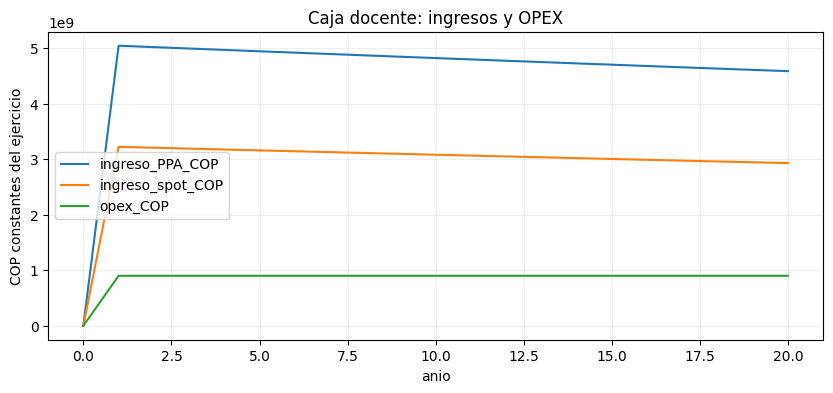

In [4]:
caja,vpn=modelos.caja_proyecto()
display(caja.head());print('VPN exploratorio, miles de millones COP constantes:',vpn/1e9)
caja.plot(x='anio',y=['ingreso_PPA_COP','ingreso_spot_COP','opex_COP'],title='Caja docente: ingresos y OPEX');plt.ylabel('COP constantes del ejercicio');plt.show()

## 2. Alternativas y escenarios comparables
El ranking se calcula. Se conserva no construir como base incremental. Mayor VPN es mejor: arrepentimiento = mejor VPN del escenario menos VPN de la opción. Se muestra además mínimo VPN para no confundir mejor comparación con aceptabilidad. El ranking no verifica conexión ni derechos.

In [5]:
valores,regret,resumen=modelos.escenarios_negocio()
display(valores);display(regret);display(resumen)
mejor=resumen.max_regret_miles_millones_COP.min()
print('Menor máximo arrepentimiento EN ESTE EJERCICIO:',resumen.index[np.isclose(resumen.max_regret_miles_millones_COP,mejor)].tolist())

Menor máximo arrepentimiento EN ESTE EJERCICIO: ['No construir']


,No construir,Solar 20 MW mercante,Solar 20 MW PPA parcial
Referencia,0.0,-5.228655,-3.495606
Precio capturado bajo,0.0,-34.112808,-15.049267
Conexión tardía,0.0,-15.428640,-13.996368
Producción baja,0.0,-28.335977,-23.136830


,No construir,Solar 20 MW mercante,Solar 20 MW PPA parcial
Referencia,0.0,5.228655,3.495606
Precio capturado bajo,0.0,34.112808,15.049267
Conexión tardía,0.0,15.428640,13.996368
Producción baja,0.0,28.335977,23.136830


,min_VPN_miles_millones_COP,max_regret_miles_millones_COP,admisible_financieramente
No construir,0.000000,0.000000,True
Solar 20 MW PPA parcial,-23.136830,23.136830,False
Solar 20 MW mercante,-34.112808,34.112808,False


## 3. CxC: ejercicio dimensional separado
Las cantidades siguientes son HIPOTÉTICAS: OEF mensual expresada en kWh, precio de cargo USD/kWh, TRM COP/USD. Multiplicar produce COP de remuneración bruta del período bajo esta simplificación. No se agrega al VPN: falta asignación, certificación y condiciones aplicables al activo. No se modela liquidación regulatoria completa.

In [6]:
oef_mes_kWh=1_000_000.  # supuesto pedagógico, no asignación real
precio_cargo_USD_kWh=.015  # supuesto pedagógico, no cotización
trm_COP_USD=4000.  # supuesto, no TRM histórica descargada
print('Remuneración bruta ilustrativa del mes COP:',oef_mes_kWh*precio_cargo_USD_kWh*trm_COP_USD)

Remuneración bruta ilustrativa del mes COP: 60000000.0


**Ejercicio abierto:** agregue un escenario de baja producción Y conexión tardía. ¿Cambia la conclusión? Distinga cambio de horizonte, desembolso CAPEX, inflación y fecha de inicio. Señale qué información contractual falta antes de recomendar un PPA real.

## Sensibilidad y escenario adverso combinado

La tabla cambia una variable a la vez y conserva su rango visible. No interpreta ese rango como probabilidad ni confunde sensibilidad con una palanca controlable. El escenario combinado pregunta por la coincidencia de tres condiciones, todavía sin probabilidades.

**Trabajo abierto:** justificar rangos con evidencia del proyecto, recalcular y discutir si el dato más sensible es también el más barato o urgente de verificar. Comparar admisibilidad financiera y máximo arrepentimiento; conexión y gobernanza siguen pendientes.

In [7]:
_,base_vpn=modelos.caja_proyecto()
variantes=[('CAPEX -20%',{'capex_COP_MW':3.2e9*.8}),
           ('CAPEX +20%',{'capex_COP_MW':3.2e9*1.2}),
           ('Factor de planta 15%',{'factor_planta':.15}),
           ('Factor de planta 25%',{'factor_planta':.25}),
           ('Precio capturado 130 COP/kWh',{'precio_captura_COP_kWh':130}),
           ('Precio capturado 330 COP/kWh',{'precio_captura_COP_kWh':330}),
           ('Demora 2 anios',{'demora_anios':2})]
sensibilidad=[]
for nombre,cambio in variantes:
    _,valor=modelos.caja_proyecto(**cambio)
    sensibilidad.append({'variacion':nombre,'VPN_miles_millones_COP':valor/1e9,
                         'cambio_VPN_miles_millones_COP':(valor-base_vpn)/1e9})
display(pd.DataFrame(sensibilidad))
ampliados={**modelos.ESCENARIOS,'Adverso combinado':{
    'factor_planta':.15,'precio_captura_COP_kWh':130.,'demora_anios':2}}
valores_ampliados,regret_ampliado,resumen_ampliado=modelos.escenarios_negocio(escenarios=ampliados)
display(valores_ampliados);display(resumen_ampliado)

,variacion,VPN_miles_millones_COP,cambio_VPN_miles_millones_COP
0,CAPEX -20%,9.304394,12.800000
1,CAPEX +20%,-16.295606,-12.800000
2,Factor de planta 15%,-20.537256,-17.041650
3,Factor de planta 25%,13.546045,17.041650
4,Precio capturado 130 COP/kWh,-15.049267,-11.553661
5,Precio capturado 330 COP/kWh,8.058056,11.553661
6,Demora 2 anios,-13.996368,-10.500763


,No construir,Solar 20 MW mercante,Solar 20 MW PPA parcial
Referencia,0.0,-5.228655,-3.495606
Precio capturado bajo,0.0,-34.112808,-15.049267
Conexión tardía,0.0,-15.428640,-13.996368
Producción baja,0.0,-28.335977,-23.136830
Adverso combinado,0.0,-47.057982,-35.241737


,min_VPN_miles_millones_COP,max_regret_miles_millones_COP,admisible_financieramente
No construir,0.000000,0.000000,True
Solar 20 MW PPA parcial,-35.241737,35.241737,False
Solar 20 MW mercante,-47.057982,47.057982,False


## Bitácora de aprendizaje
Escribe cuatro párrafos: qué esperabas; qué observaste; qué regla explica la diferencia; qué se puede trasladar al problema energético y qué requiere otro análisis. Incluye una variante ejecutada y un resultado que podría refutar tu explicación. Una limitación debe conducir a una pregunta o prueba concreta.